4540
[4541, 3100, 2286, 1538, 1338, 1102, 966, 532, 274, 212, 186, 131]
[1.00022026 0.68281938 0.50352423 0.33876652 0.29471366 0.24273128
 0.21277533 0.11718062 0.06035242 0.04669604 0.04096916 0.02885463]
tau_0m: 653926
tau_0p: 4346075
[1.00022026 0.68281938 0.50352423 0.33876652 0.29471366 0.24273128
 0.21277533 0.11718062 0.06035242 0.04669604 0.04096916 0.02885463]
5000001
Ndiscard_start: 76405
Ndiscard_end: 1
5000001 ==  5000001
tau_0min: 127.23529411764706
tau_0plus: 957.2850220264318
tau_test: 1084.5203161440788
f_test =  0.04610333181933448


/tmp/ipykernel_595923/1803622486.py:92: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


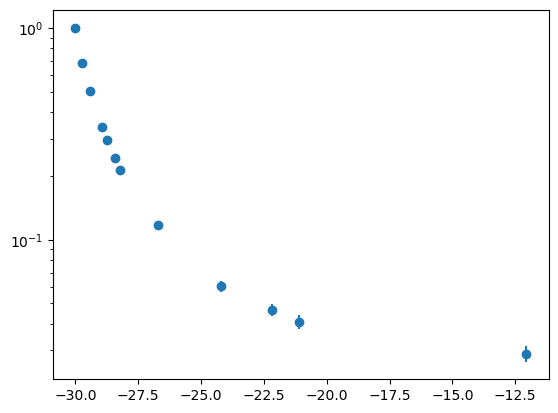

In [9]:
# LONG MD RUN
import numpy as np
import matplotlib.pyplot as plt 
with open("../simulations/recalc_1us.txt", "r") as f:
    t, d = np.loadtxt(f, unpack=True, usecols=(0,1))

# fig, ax = plt.subplots()
# ax.plot(t[::1000], d[::1000])
# fig.show()

testd = -abs(d)
# intfs = [4.0, 4.15, 4.3, 4.45, 4.60, 4.80, 5.0, 5.33, 5.66, 6., 6.33, 6.66, 7.0, 7.25, 7.5, 7.75, 8.0, 8.33, 8.66, 9.0, 9.33]
# intfs = [
#     -30.0,
#     -29.0,
#     -25.8,
#     -22.0,
#     -18.0,
#     -13.0,
#     -10.5,
#     -8.6,
#     -5.5,
#     -1.0,
#     4.0,
#     8.0,
#     13.0,
#     18.0,
#     20.0,
#     22.0,
#     25.0,
#     30.0
# ]
intfs = [
    -30.0,
    -29.72,
    -29.42,
    -28.95,
    -28.75,
    -28.42,
    -28.21,
    -26.7,
    -24.21,
    -22.18,
    -21.11,
    -12.06]

lambda_A = -30.0
# lamb = -22.0
# first we calculate how many times the particle goes through lambda_A (left to right, postivie flux)
Arun = testd < lambda_A
Arun = np.diff(Arun.astype(int))
Arun = np.where(Arun == 1)[0]
# already_crossed = False
# n_cross = 0
# for ph in testd:
#     if ph > lamb and not already_crossed:
#         n_cross += 1
#         already_crossed = True
#     elif ph < lambda_A:
#         already_crossed = False
# print(Arun)
# print(len(Arun))
# print(n_cross)
# print(n_cross/len(Arun))

# now we do it simultaneously for multiple lambs
# lambs = [4.15, 4.30, 4.45, 4.60, 4.80, 5.0, 5.33, 5.66, 6., 6.33, 6.66, 7.0]
lambs = intfs[:]
tau_0m = 0
tau_0p = 0
already_crosseds = [False for _ in lambs]
n_crosss = [0 for _ in lambs]
for ph in testd:
    tau_0m += ph < lambda_A
    tau_0p += ph > lambda_A
    for i, lamb in enumerate(lambs):
        if ph > lamb and not already_crosseds[i]:
            n_crosss[i] += 1
            already_crosseds[i] = True
        elif ph < lambda_A:
            already_crosseds[i] = False

print(len(Arun))
print(n_crosss)
print(np.array(n_crosss)/len(Arun))

probs = np.array(n_crosss)/len(Arun)
stderrs = np.sqrt(n_crosss)/len(Arun)
fig, ax = plt.subplots()
ax.errorbar(lambs, probs, yerr=stderrs, fmt="o")
ax.set_yscale("log")
fig.show()

print("tau_0m:", tau_0m)
print("tau_0p:", tau_0p)
print(probs)
print(tau_0m + tau_0p)

# testd[:100] --> we see that:
# trajectory starts somewhere lambda < lambda_A. 
# So the first Ndiscard_start phasepoints must be 
# discarded, as they are not part of any ensemlbe.
start = np.where(testd < lambda_A)[0][0]
Ndiscard_start = np.where(testd[start:] > lambda_A)[0][0] + start
# testd[-100:] --> we see that:
# trajectory ends somewhere lambda < lambda_A.
# So the last Ndiscard_end phasepoints must be
# discarded, as they are not part of any ensemble.
Ndiscard_end = len(testd) - np.where(testd > lambda_A)[0][-1]

# so in this case, for N positive lambda_A crossings, 
# we have N 0+ trajectories, and we have N - 1
# 0- trajectories. 

# apparently, we also have 43 phasepoints that 
# are exactly equal to lambda_A. So we add half 
# of these to 0+, and half to 0-...

print("Ndiscard_start:", Ndiscard_start)
print("Ndiscard_end:", Ndiscard_end)

tau_0min = (tau_0m - Ndiscard_start + np.sum(testd == lambda_A)/2) / (len(Arun) - 1)
tau_0plus = (tau_0p - Ndiscard_end + np.sum(testd == lambda_A)/2) / len(Arun)

# sanity check:
print(tau_0m + tau_0p + np.sum(testd == lambda_A), "== ", len(testd))

print("tau_0min:", tau_0min)
print("tau_0plus:", tau_0plus)

tau_test = tau_0min + tau_0plus 
print("tau_test:", tau_test)
print("f_test = ", 1 / tau_test / 0.02)  # ps^-1


tau_0m: 22237862
tau_0p: 2762096
[5.47462974e-02 2.79823601e-03 4.09285557e-04 6.74885759e-05
 1.30623050e-05 2.17705084e-06 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00]
24999958


In [1]:
# LONG MD RUN
import numpy as np
import matplotlib.pyplot as plt 
with open("distance.dat", "r") as f:
    t, d = np.loadtxt(f, unpack=True)
    
intfs = [4.0, 4.15, 4.3, 4.45, 4.60, 4.80, 5.0, 5.33, 5.66, 6., 6.33, 6.66, 7.0, 7.25, 7.5, 7.75, 8.0, 8.33, 8.66, 9.0, 9.33]
lambda_A = 4

In [3]:
len(d)

25000001

In [4]:
25000001/10

2500000.1

In [ ]:
fs, tau_0ms, tau_0ps, taus = [], [], [], []

for i in range(1, 11):
    print(f"########################\n i = {i}\n#############################")
    testd = d[:i*2500000]

    Arun = testd < lambda_A
    Arun = np.diff(Arun.astype(int))
    Arun = np.where(Arun == 1)[0]
    # already_crossed = False
    # n_cross = 0
    # for ph in testd:
    #     if ph > lamb and not already_crossed:
    #         n_cross += 1
    #         already_crossed = True
    #     elif ph < lambda_A:
    #         already_crossed = False
    # print(Arun)
    # print(len(Arun))
    # print(n_cross)
    # print(n_cross/len(Arun))

    # now we do it simultaneously for multiple lambs
    # lambs = [4.15, 4.30, 4.45, 4.60, 4.80, 5.0, 5.33, 5.66, 6., 6.33, 6.66, 7.0]
    lambs = intfs[:10]
    tau_0m = 0
    tau_0p = 0
    already_crosseds = [False for _ in lambs]
    n_crosss = [0 for _ in lambs]
    for ph in testd:
        tau_0m += ph < lambda_A
        tau_0p += ph > lambda_A
        for i, lamb in enumerate(lambs):
            if ph > lamb and not already_crosseds[i]:
                n_crosss[i] += 1
                already_crosseds[i] = True
            elif ph < lambda_A:
                already_crosseds[i] = False

    print(len(Arun))
    print(n_crosss)
    print(np.array(n_crosss)/len(Arun))

    probs = np.array(n_crosss)/len(Arun)
    stderrs = np.sqrt(n_crosss)/len(Arun)
    # fig, ax = plt.subplots()
    # ax.errorbar(lambs, probs, yerr=stderrs, fmt="o")
    # ax.set_yscale("log")
    # fig.show()

    print("tau_0m:", tau_0m)
    print("tau_0p:", tau_0p)
    print(probs)
    print(tau_0m + tau_0p)

    # testd[:100] --> we see that:
    # trajectory starts somewhere lambda < lambda_A. 
    # So the first Ndiscard_start phasepoints must be 
    # discarded, as they are not part of any ensemlbe.
    Ndiscard_start = 0 #np.where(testd > lambda_A)[0][0]
    # testd[-100:] --> we see that:
    # trajectory ends somewhere lambda < lambda_A.
    # So the last Ndiscard_end phasepoints must be
    # discarded, as they are not part of any ensemble.
    Ndiscard_end = 0 #len(testd) - np.where(testd < lambda_A)[0][-1]

    # so in this case, for N positive lambda_A crossings, 
    # we have N 0+ trajectories, and we have N - 1
    # 0- trajectories. 

    # apparently, we also have 43 phasepoints that 
    # are exactly equal to lambda_A. So we add half 
    # of these to 0+, and half to 0-...

    print("Ndiscard_start:", Ndiscard_start)
    print("Ndiscard_end:", Ndiscard_end)

    tau_0min = (tau_0m - Ndiscard_start + np.sum(testd == lambda_A)/2) / (len(Arun) - 1)
    tau_0plus = (tau_0p - Ndiscard_end + np.sum(testd == lambda_A)/2) / len(Arun)

    # sanity check:
    print(tau_0m + tau_0p + np.sum(testd == lambda_A), "== ", len(testd))

    print("tau_0min:", tau_0min)
    print("tau_0plus:", tau_0plus)

    tau_test = tau_0min + tau_0plus 
    print("tau_test:", tau_test)
    print("f_test = ", 1 / tau_test / 0.02)  # ps^-1
    
    # append ot lists
    fs.append(1 / tau_test / 0.02)
    tau_0ms.append(tau_0min)
    tau_0ps.append(tau_0plus)
    taus.append(tau_test)
    


########################
 i = 1
#############################
1010
[1010, 586, 399, 364, 351, 349, 347, 340, 338, 334]
[1.         0.58019802 0.3950495  0.36039604 0.34752475 0.34554455
 0.34356436 0.33663366 0.33465347 0.33069307]
tau_0m: 84784
tau_0p: 915217
[1.         0.58019802 0.3950495  0.36039604 0.34752475 0.34554455
 0.34356436 0.33663366 0.33465347 0.33069307]
1000001
Ndiscard_start: 0
Ndiscard_end: 0
1000001 ==  1000001
tau_0min: 84.02775024777007
tau_0plus: 906.1554455445545
tau_test: 990.1831957923246
f_test =  0.05049570646368221
########################
 i = 2
#############################
1010
[1010, 586, 399, 364, 351, 349, 347, 340, 338, 334]
[1.         0.58019802 0.3950495  0.36039604 0.34752475 0.34554455
 0.34356436 0.33663366 0.33465347 0.33069307]
tau_0m: 84784
tau_0p: 915217
[1.         0.58019802 0.3950495  0.36039604 0.34752475 0.34554455
 0.34356436 0.33663366 0.33465347 0.33069307]
1000001
Ndiscard_start: 0
Ndiscard_end: 0
1000001 ==  1000001
tau_0min: 84.

In [6]:
# we have ten blocks of data, for which we calculated tau_0m, tau_0p, tau, and f.
# So we calculate the mean and the standard error of these values 

fs = np.array(fs)
tau_0ms = np.array(tau_0ms)
tau_0ps = np.array(tau_0ps)
taus = np.array(taus)

print("fs:", fs)
print("tau_0ms:", tau_0ms)
print("tau_0ps:", tau_0ps)
print("taus:", taus)

print("mean fs:", np.mean(fs), "stderrs:", np.std(fs)/np.sqrt(len(fs)))
print("mean tau_0ms:", np.mean(tau_0ms), "stderrs:", np.std(tau_0ms)/np.sqrt(len(tau_0ms)))
print("mean tau_0ps:", np.mean(tau_0ps), "stderrs:", np.std(tau_0ps)/np.sqrt(len(tau_0ps)))
print("mean taus:", np.mean(taus), "stderrs:", np.std(taus)/np.sqrt(len(taus))) 

# relative percentage error
print("relative percentage error fs:", np.std(fs)/np.mean(fs) * 100)
print("relative percentage error tau_0ms:", np.std(tau_0ms)/np.mean(tau_0ms) * 100)
print("relative percentage error tau_0ps:", np.std(tau_0ps)/np.mean(tau_0ps) * 100)
print("relative percentage error taus:", np.std(taus)/np.mean(taus) * 100) 


fs: [0.05049571 0.05049571 0.05049571 0.05049571 0.05049571 0.05049571
 0.05049571 0.05049571 0.05049571 0.05049571]
tau_0ms: [84.02775025 84.02775025 84.02775025 84.02775025 84.02775025 84.02775025
 84.02775025 84.02775025 84.02775025 84.02775025]
tau_0ps: [906.15544554 906.15544554 906.15544554 906.15544554 906.15544554
 906.15544554 906.15544554 906.15544554 906.15544554 906.15544554]
taus: [990.18319579 990.18319579 990.18319579 990.18319579 990.18319579
 990.18319579 990.18319579 990.18319579 990.18319579 990.18319579]
mean fs: 0.05049570646368221 stderrs: 0.0
mean tau_0ms: 84.02775024777007 stderrs: 0.0
mean tau_0ps: 906.1554455445545 stderrs: 0.0
mean taus: 990.1831957923245 stderrs: 3.595093471822542e-14
relative percentage error fs: 0.0
relative percentage error tau_0ms: 0.0
relative percentage error tau_0ps: 0.0
relative percentage error taus: 1.1481394372749998e-14


In [14]:
intfsMD = [4., 4.15, 4.30, 4.45, 4.60, 4.80, 5.0, 5.33, 5.66, 6., 6.33, 6.66, 7.0][:-1]

probsMD = [1.,0.08347785717838609, 0.013032016314890654, 0.005167487385251383, 
           0.0021841615129960927, 0.0006764710758874538, 0.00021554225457198282, 
           5.526724476204688e-05, 1.9896208114336877e-05, 1.326413874289125e-05, 
           7.737414266686563e-06, 4.4213795809637505e-06]

stderrs = [0., 0.0003037627747071407, 0.0001200203012342537, 7.557682053718294e-05, 
           4.9135036163332104e-05, 2.7344722534894038e-05, 1.5435301448299086e-05, 
           7.815968709748009e-06, 4.689581225848805e-06, 3.829027036888404e-06, 
           2.9244677057622633e-06, 2.2106897904818752e-06]
probsMD, stderrs = np.array(probsMD), np.array(stderrs)

fig, ax = plt.subplots()

ax.plot(lambs, probs, label = "MD new")

ax.plot(intfsMD[:], probsMD[:], color='r', label="MD old", marker="x")
# shade the MD errorbars 
ax.fill_between(intfsMD[:], probsMD[:]-stderrs[:], probsMD[:]+stderrs[:], color='r', alpha=0.3)

ax.legend()

ax.set_xlabel(r'$\lambda [\mathrm{\AA}]$')
ax.set_ylabel(r'$P_A(\lambda_i|\lambda_A)$')
ax.set_yscale("log")
fig.tight_layout()
fig.savefig('md-newrun.png', dpi=300)
fig.show()


In [34]:
intfsMD = [4., 4.15, 4.30, 4.45, 4.60, 4.80, 5.0, 5.33, 5.66, 6., 6.33, 6.66, 7.0][:-1]
counts = [75522, 11790, 4675, 1976, 612, 195, 50, 18, 12, 7, 4] # then zeros

probsMD = [1.,0.08347785717838609, 0.013032016314890654, 0.005167487385251383, 
           0.0021841615129960927, 0.0006764710758874538, 0.00021554225457198282, 
           5.526724476204688e-05, 1.9896208114336877e-05, 1.326413874289125e-05, 
           7.737414266686563e-06, 4.4213795809637505e-06]

stderrs = [0., 0.0003037627747071407, 0.0001200203012342537, 7.557682053718294e-05, 
           4.9135036163332104e-05, 2.7344722534894038e-05, 1.5435301448299086e-05, 
           7.815968709748009e-06, 4.689581225848805e-06, 3.829027036888404e-06, 
           2.9244677057622633e-06, 2.2106897904818752e-06]

counts, probsMD, stderrs = np.array(counts), np.array(probsMD), np.array(stderrs)
# newerrs = 1/np.sqrt(counts) *probsMD

positive_acrossings = len(Arun)
timestep = 0.002*10 # ps
lentraj = len(d)
fluxMD = positive_acrossings/(lentraj*timestep)
print(fluxMD, "ps^-1")

2.756021889759124 ps^-1


In [ ]:
fig, ax = plt.subplots(figsize=(4.333333,3))
ax.plot(total_prob[:,0][:12], total_prob[:,1][:12], color='k',label="REPPTIS", marker="x")
ax.plot(intfsMD[:], probsMD[:], color='r', label="MD", marker="x")
# shade the MD errorbars 
ax.fill_between(intfsMD[:], probsMD[:]-stderrs[:], probsMD[:]+stderrs[:], color='r', alpha=0.3)
ax.set_xlabel(r'$\lambda [\mathrm{\AA}]$')
ax.set_ylabel(r'$P_A(\lambda_i|\lambda_A)$')
ax.set_yscale('log')
# vlines at every x value 
for x in total_prob[:,0][:12]:
    ax.axvline(x, color='k', linestyle='--', lw=1, alpha=0.3)
# scientific notation y
# xlabels at 4, 9, 14, 18
ax.set_xticks([4, 4.5, 5, 5.5, 6, 6.5])
ax.set_xticklabels(["4", "4.5", "5", "5.5", "6", "6.5"])
ax.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0])

# textboxes in right upper corner saying MD in black and REPPTIS in RED
# background of textbox is white. Put both in same box, but in two lines
ax.text(0.95, 0.95, "MD", fontsize=15, ha='right', va='top', transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='white'), color="r")
ax.text(0.95, 0.8, "REPPTIS", fontsize=15, ha='right', va='top', transform=ax.transAxes, bbox=dict(facecolor='white', edgecolor='white'), color='k')
fig.tight_layout(pad=0.75)
fig.savefig('total-prob-MD.pdf')
fig.show()

In [75]:
# let's shift the MD data down on the log plot, such that the 
# two last points of probsMD and total_prob[:12,1] are 
# touching. 
fig, ax = plt.subplots(figsize=(3.333333,3))
ax.plot(total_prob[:,0][:12], total_prob[:,1][:12], linestyle='-',marker="x", color='k',label="REPPTIS")
ax.plot(intfsMD, probsMD*10**(-3), color='r', label="MD",marker="x")
ax.set_xlabel(r'$\lambda [\mathrm{\AA}]$')
ax.set_ylabel(r'$P_A(\lambda_i|\lambda_A)$')
ax.set_yscale('log')
ax.set_yticks([1e-10, 1e-8, 1e-6, 1e-4, 1e-2, 1e0])
# vlines at every x value 
for x in total_prob[:,0]:
    ax.axvline(x, color='k', linestyle='--', lw=1, alpha=0.3)
# scientific notation y
# xlabels at 4, 9, 14, 18
ax.set_xticks([4, 9, 14, 19])

fig.tight_layout()
fig.savefig('total-prob-MD.pdf')
fig.show()


In [90]:
probsMD[-1]/total_prob[11,1] * 2.174267773886322 * 2.471425098 * 1e-14

6.352397417769115e-10

In [66]:
total_prob[11,1]

3.7400776798010123e-10

In [8]:
fluxMD

2.7373148690395066